Mounted at /content/drive
X shape : (4852, 128, 128)
y shape : (4852,)
X dtype : float32
y dtype : int64

===== SANITY CHECKS =====
✅ X shape  : (4852, 128, 128)  (samples, time, mel) — axis-1 is time ✓
✅ y shape  : (4852,)
✅ No NaN / Inf
✅ 8 classes found : [0 1 2 3 4 5 6 7]

Class Distribution:
  0  neutral         588  (12.1%)
  1  calm            376  (7.7%)  ⚠️  RAVDESS only
  2  happy           776  (16.0%)
  3  sad             776  (16.0%)
  4  angry           776  (16.0%)
  5  fearful         776  (16.0%)
  6  surprise        192  (4.0%)
  7  disgust         592  (12.2%)

Imbalance ratio: 4.0x

After normalisation — min: 0.0000  max: 1.0000
X_train : (3881, 128, 128)   y_train : (3881,)
X_val   : (971, 128, 128)   y_val   : (971,)

Class weights:
  0  neutral       1.0322
  1  calm          1.6117
  2  happy         0.7812
  3  sad           0.7812
  4  angry         0.7812
  5  fearful       0.7812
  6  surprise      3.1708
  7  disgust       1.0256


Model: "BiGRU_SER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 128, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │     24,640 │ mel_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 64)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 64)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128, 128)  │          0 │ mel_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 128, 1)    │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128)  │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 128, 1)    │          0 │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128)  │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool (MaxPool)  │ (None, 64, 1)     │          0 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 128)   │          0 │ dropout_1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze (Squeeze)   │ (None, 64)        │          0 │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ max_pooling1d[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 64)        │          0 │ squeeze[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_gru              │ [(None, 64, 128), │     74,496 │ layer_normalizat… │
│ (Bidirectional)     │ (None, 64),       │            │ cast_1[0][0]      │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ bi_gru[0][1],     │
│ (Concatenate)       │                   │            │ bi_gru[0][2]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 166,408 (650.03 KB)

 Trainable params: 166,280 (649.53 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.2979 - loss: 1.9620
Epoch 1: val_loss improved from None to 1.36002, saving model to best_bigru.keras

Epoch 1: finished saving model to best_bigru.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - accuracy: 0.4146 - loss: 1.6990 - val_accuracy: 0.5942 - val_loss: 1.3600 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.6380 - loss: 1.2758
Epoch 2: val_loss improved from 1.36002 to 1.19626, saving model to best_bigru.keras

Epoch 2: finished saving model to best_bigru.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 24s 400ms/step - accuracy: 0.6671 - loss: 1.2037 - val_accuracy: 0.6715 - val_loss: 1.1963 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7339 - loss: 1.0848
Epoch 3: val_loss improved from 1.19626 to 1.08037, saving model to best_bigru.keras

Epoch 3: finished saving model to best_bigru.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 27s 446ms/step - acc

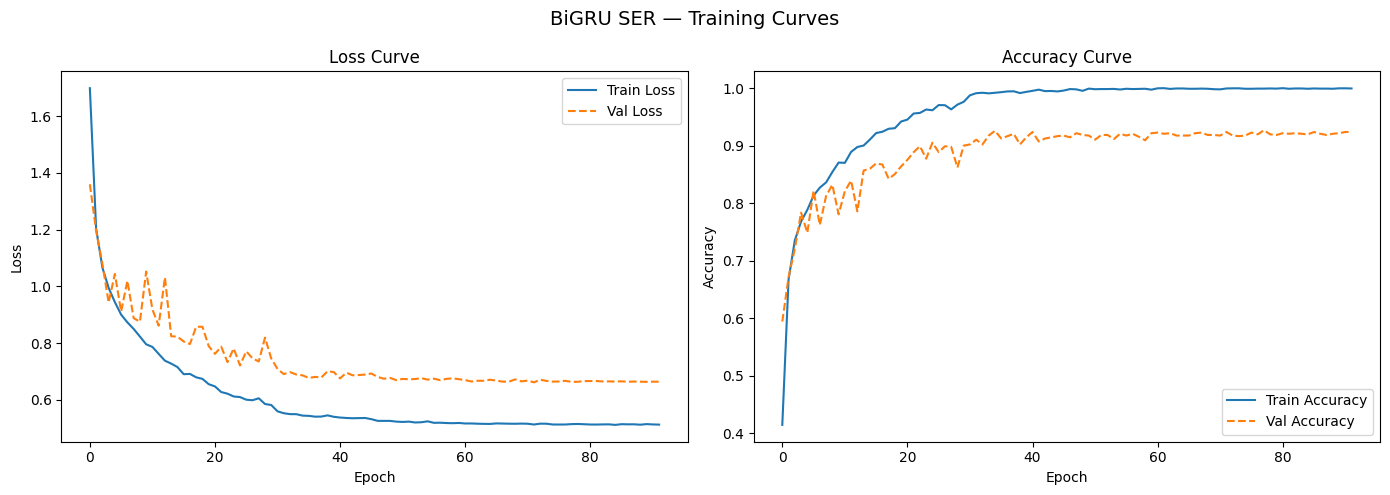

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9238 - loss: 0.6616

Validation Loss    : 0.6616
Validation Accuracy: 0.9238
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.94      0.94       118
        calm       0.85      0.85      0.85        75
       happy       0.95      0.93      0.94       155
         sad       0.92      0.87      0.89       155
       angry       0.94      0.97      0.96       155
     fearful       0.88      0.92      0.90       155
    surprise       0.95      0.90      0.92        39
     disgust       0.94      0.97      0.96       119

    accuracy                           0.92       971
   macro avg       0.92      0.92      0.92       971
weighted avg       0.92      0.92      0.92       971



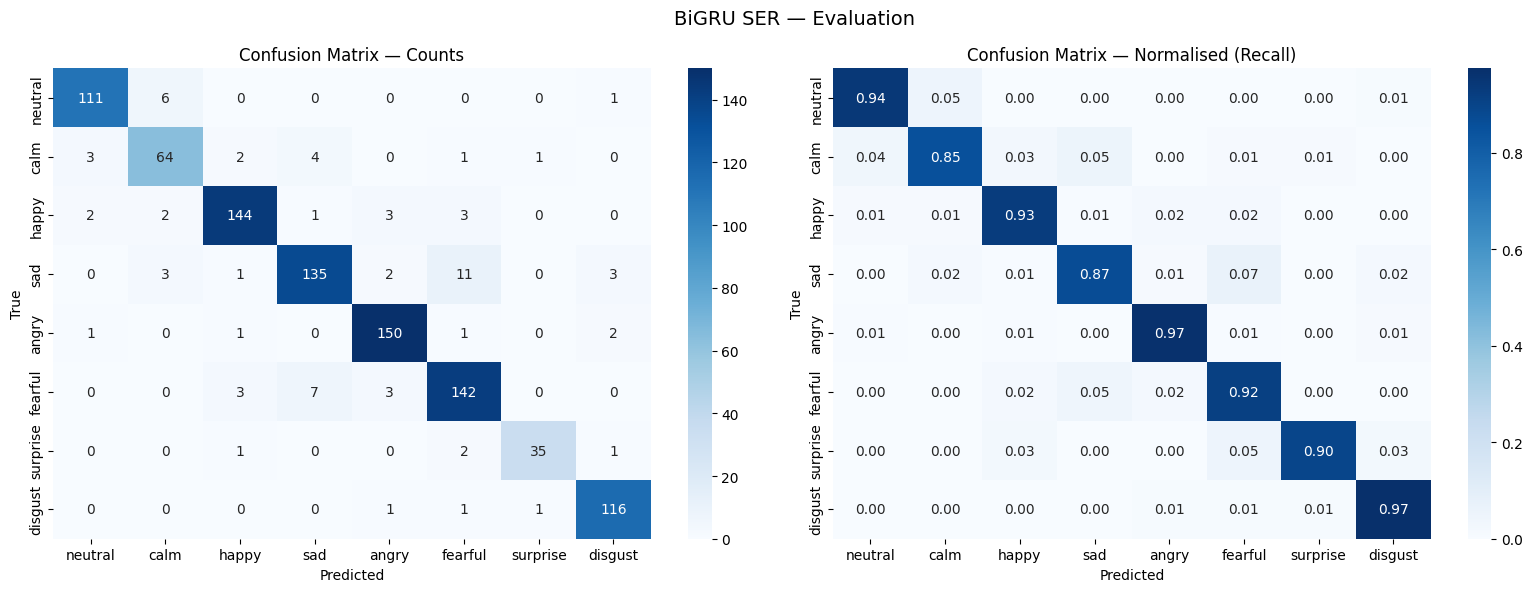

In [1]:
# ================================================================
# BiGRU Speech Emotion Recognition — Final Version
# ================================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras.ops as kops
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Fix 2 + 3: exact same order and spelling as pipeline LABEL2IDX
EMOTION_LABELS = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "surprise",
    "disgust",
]
NUM_CLASSES = len(EMOTION_LABELS)


# ================================================================
# 🔹 1. LOAD DATA
# ================================================================

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/SER_Project/"

# Fix 1: load the fixed files produced by the corrected pipeline
X = np.load(DATA_PATH + "X_fixed_final.npy")
y = np.load(DATA_PATH + "y_fixed_final.npy")

print("X shape :", X.shape)
print("y shape :", y.shape)
print("X dtype :", X.dtype)
print("y dtype :", y.dtype)


# ================================================================
# 🔹 2. SANITY CHECKS
# ================================================================

print("\n===== SANITY CHECKS =====")
assert len(X.shape) == 3,          f"❌ Expected 3-D X, got {X.shape}"
assert X.shape[1] == 128,          f"❌ Expected time=128 on axis-1, got {X.shape[1]}"
assert X.shape[2] == 128,          f"❌ Expected mel=128 on axis-2, got {X.shape[2]}"
assert np.isnan(X).sum() == 0,     "❌ NaN in X"
assert np.isinf(X).sum() == 0,     "❌ Inf in X"
assert len(np.unique(y)) == NUM_CLASSES, \
    f"❌ Expected {NUM_CLASSES} classes, got {len(np.unique(y))}"

print(f"✅ X shape  : {X.shape}  (samples, time, mel) — axis-1 is time ✓")
print(f"✅ y shape  : {y.shape}")
print(f"✅ No NaN / Inf")
print(f"✅ {NUM_CLASSES} classes found : {np.unique(y)}")

print("\nClass Distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    note = "  ⚠️  RAVDESS only" if EMOTION_LABELS[u] == "calm" else ""
    print(f"  {u}  {EMOTION_LABELS[u]:<12s}  {c:5d}  ({c/len(y)*100:.1f}%){note}")
print(f"\nImbalance ratio: {counts.max()/counts.min():.1f}x")


# ================================================================
# 🔹 3. NORMALISE  (mel dB range −80…0  →  0…1)
# ================================================================

X_min = X.min()
X_max = X.max()
X     = ((X - X_min) / (X_max - X_min + 1e-8)).astype(np.float32)

print(f"\nAfter normalisation — min: {X.min():.4f}  max: {X.max():.4f}")
# Padding frames (zeros in raw data) become exactly 0.0 after normalisation
# → mask logic (any value != 0) correctly identifies them as padded


# ================================================================
# 🔹 4. TRAIN / VAL SPLIT  (stratified 80 / 20)
# ================================================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}   y_val   : {y_val.shape}")


# ================================================================
# 🔹 5. CLASS WEIGHTS  (handles calm imbalance + disgust scarcity)
# ================================================================

cw_array      = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(cw_array))
print("\nClass weights:")
for idx, w in class_weights.items():
    print(f"  {idx}  {EMOTION_LABELS[idx]:<12s}  {w:.4f}")


# ================================================================
# 🔹 6. LABEL SMOOTHING LOSS
# ================================================================
# Runs in eager mode at train time → tf.* is fine here.
# Accepts INTEGER labels directly — no one-hot needed.

smoothing  = 0.1
confidence = 1.0 - smoothing

@tf.function
def label_smoothing_loss(y_true, y_pred):
    y_true  = tf.cast(tf.squeeze(y_true), tf.int32)
    one_hot = tf.one_hot(y_true, NUM_CLASSES)
    smooth  = one_hot * confidence + smoothing / NUM_CLASSES
    log_p   = tf.math.log(tf.clip_by_value(y_pred, 1e-9, 1.0))
    return tf.reduce_mean(-tf.reduce_sum(smooth * log_p, axis=-1))


# ================================================================
# 🔹 7. HYPERPARAMETERS
# ================================================================

hidden_dim    = 128
kernel_size   = 3
conv_dropout  = 0.2
gru_dropout   = 0.1
dense_dropout = 0.1
learning_rate = 1e-3


# ================================================================
# 🔹 8. BUILD BiGRU MODEL
# ================================================================
# ── Input ────────────────────────────────────────────────────────
inp = keras.Input(shape=(128, 128), name="mel_input")
# shape: (batch, time=128, mel=128)



# ── Padding Mask ──────────────────────────────────────────────────


real_frame = kops.cast(
    kops.any(inp != 0.0, axis=-1, keepdims=True),  # (B, 128, 1)
    dtype="float32"
)

# Downsample mask to match post-MaxPool1D(2) sequence length (128→64)
real_pooled = kops.max_pool(
    real_frame,
    pool_size=(2,),
    strides=(2,),
    padding="valid"
)                                                   # (B, 64, 1)

# gru_mask  : bool  (B, 64)     False=padded → GRU skips frame
# attn_mask : float (B, 64, 1)  1.0=padded  → score pushed to -inf
gru_mask  = kops.cast(kops.squeeze(real_pooled, axis=-1), "bool")
attn_mask = 1.0 - real_pooled


# ── CNN Front-end ─────────────────────────────────────────────────
# Conv1D slides over axis-1 (time)
# Two blocks extract local spectro-temporal patterns before the GRU.

x = layers.Conv1D(hidden_dim // 2, kernel_size, padding="same",
                  kernel_initializer="he_normal")(inp)
x = layers.LayerNormalization(axis=-1)(x)
x = layers.Activation("gelu")(x)
x = layers.Dropout(conv_dropout)(x)

x = layers.Conv1D(hidden_dim, kernel_size, padding="same",
                  kernel_initializer="he_normal")(x)
x = layers.LayerNormalization(axis=-1)(x)
x = layers.Activation("gelu")(x)
x = layers.Dropout(conv_dropout)(x)

# MaxPool: (B, 128, hidden_dim) → (B, 64, hidden_dim)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.LayerNormalization(axis=-1)(x)


# ── Bidirectional GRU ─────────────────────────────────────────────
#   cuDNN GRU kernel validates masks and rejects anything it
#   considers non-right-padded (even valid masks in some Keras/TF
#   versions). The standard kernel has no such restriction.
#   Trade-off: ~10-20% slower per epoch — acceptable for correctness.
#
# return_sequences=True  → all 64 timestep outputs for attention
# return_state=True      → final fwd + bwd hidden states for query
# recurrent_dropout=0.0  → keep 0; recurrent dropout forces CPU mode
#                          and conflicts with use_cudnn=False logic
# orthogonal init        → proven stable recurrent weight init

gru_out, fwd_h, bwd_h = layers.Bidirectional(
    layers.GRU(
        hidden_dim // 2,
        return_sequences=True,
        return_state=True,
        dropout=gru_dropout,
        recurrent_dropout=0.0,
        kernel_initializer="glorot_uniform",
        recurrent_initializer="orthogonal",
        use_cudnn=False,
    ),
    name="bi_gru"
)(x, mask=gru_mask)
# gru_out : (B, 64, hidden_dim)
# fwd_h   : (B, hidden_dim // 2)
# bwd_h   : (B, hidden_dim // 2)


# ── Bahdanau Attention ────────────────────────────────────────────
# Query  = concat of final forward + backward hidden states
# Key/V  = all GRU timestep outputs
# Mask   = 1.0 on padded positions → score set to -inf → weight ≈ 0

h_cat  = layers.Concatenate()([fwd_h, bwd_h])      # (B, hidden_dim)
query  = layers.Reshape((1, hidden_dim))(h_cat)     # (B, 1, hidden_dim)

# Project query and keys to common space then score
Wq_out = layers.Dense(hidden_dim, use_bias=False,
                       kernel_initializer="glorot_uniform")(query)
Wk_out = layers.Dense(hidden_dim, use_bias=False,
                       kernel_initializer="glorot_uniform")(gru_out)

# Fix 5: kops.tanh instead of tf.nn.tanh
score  = layers.Dense(1, use_bias=False,
                       kernel_initializer="he_normal")(
           kops.tanh(Wq_out + Wk_out)
         )                                           # (B, 64, 1)

score   = score + (attn_mask * -1e9)                # push padded to -inf
weights = kops.softmax(score, axis=1)               # (B, 64, 1)
context = kops.sum(weights * gru_out, axis=1)       # (B, hidden_dim)


# ── Classification Head ───────────────────────────────────────────
x   = layers.Dense(hidden_dim // 2,
                    kernel_initializer="he_normal")(context)
x   = layers.BatchNormalization()(x)
x   = layers.Activation("gelu")(x)
x   = layers.Dropout(dense_dropout)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)


# ── Assemble ──────────────────────────────────────────────────────
model = keras.Model(inputs=inp, outputs=out, name="BiGRU_SER")
model.summary()


# ================================================================
# 🔹 9. COMPILE
# ================================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss=label_smoothing_loss,
    metrics=["accuracy"]
)


# ================================================================
# 🔹 10. CALLBACKS
# ================================================================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_bigru.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ================================================================
# 🔹 11. TRAIN
# ================================================================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


# ================================================================
# 🔹 12. PLOT TRAINING CURVES
# ================================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss", linestyle="--")
plt.title("Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy", linestyle="--")
plt.title("Accuracy Curve")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.suptitle("BiGRU SER — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()


# ================================================================
# 🔹 13. EVALUATE
# ================================================================

loss, acc = model.evaluate(X_val, y_val, verbose=1)
print(f"\nValidation Loss    : {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")


# ================================================================
# 🔹 14. CLASSIFICATION REPORT
# ================================================================

y_pred = np.argmax(model.predict(X_val), axis=1)

print("\nClassification Report:")
# Fix 2: target_names uses EMOTION_LABELS which now matches y encoding
print(classification_report(y_val, y_pred, target_names=EMOTION_LABELS))


# ================================================================
# 🔹 15. CONFUSION MATRIX
# ================================================================

cm      = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.title("Confusion Matrix — Counts")
plt.xlabel("Predicted"); plt.ylabel("True")

plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.title("Confusion Matrix — Normalised (Recall)")
plt.xlabel("Predicted"); plt.ylabel("True")

plt.suptitle("BiGRU SER — Evaluation", fontsize=14)
plt.tight_layout()
plt.show()


# # ================================================================
# # 🔹 16. SAVE
# # ================================================================

# model.save("bigru_ser_final.keras")
# print("✅  Model saved → bigru_ser_final.keras")